# 🚢 Titanic Data Cleaning Project

This notebook performs end-to-end data cleaning on the Titanic dataset.

**Steps covered:**
1. Import Libraries
2. Load & Explore Dataset
3. Handle Missing Values
4. Remove Unnecessary Columns
5. Handle Outliers
6. Format & Standardize Columns
7. Fix Data Types
8. Remove Duplicate Rows
9. Save Cleaned Data
10. Data Cleaning Report

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load & Explore Dataset

### 2.1 Load Dataset

In [2]:
df = pd.read_csv('titanic_data.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 2.2 Dataset Shape
Check the number of rows and columns.

In [3]:
df.shape

(891, 12)

### 2.3 Column Info & Data Types
Inspect column names, non-null counts, and data types.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 2.4 Statistical Summary
View basic statistics for numeric columns.

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 2.5 Missing Values Overview
Count missing values in each column.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df['Age'].isnull().sum()

np.int64(177)

Text(0, 0.5, 'Total Missing Values')

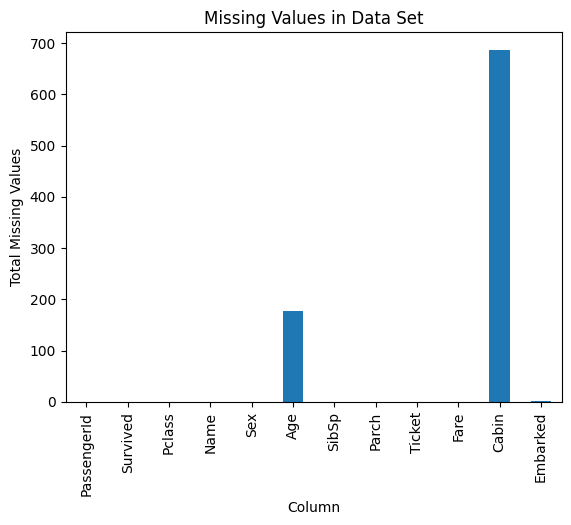

In [8]:
df.isnull().sum().plot(kind = 'bar')
plt.title('Missing Values in Data Set')
plt.xlabel('Column')
plt.ylabel('Total Missing Values')

## 3. Handle Missing Values

### 3.1 Age Column
`Age` has **177 missing values**. We fill them with the **median** age to avoid skewing the data.

In [9]:
df['Age'].isnull().sum()

np.int64(177)

In [10]:
# df['Age'].fillna(df['Age'].median(), inplace = True)
df['Age'] = df['Age'].fillna(df['Age'].median())

### 3.2 Fare Column
`Fare` has **no missing values** — no action needed.

In [11]:
df['Fare'].isnull().sum()

np.int64(0)

### 3.3 Embarked Column
`Embarked` has **2 missing values**. We fill them with the **mode** (most frequent port).

In [12]:
df['Embarked'].isnull().sum()

np.int64(2)

In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode() [0])

In [14]:
df['Embarked'].isnull().sum()

np.int64(0)

### 3.4 Cabin Column — Drop
`Cabin` has **687 missing values** (~77% of data). Too many to fill reliably, so we drop the entire column.

In [15]:
df['Cabin'].isnull().sum()

np.int64(687)

In [16]:
df.drop(['Cabin'], axis = 1, inplace = True)

### 3.5 Verify — No Missing Values Remain

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 4. Remove Unnecessary Columns

The columns `PassengerId`, `Name`, and `Ticket` are identifiers that carry no predictive value for analysis, so we drop them.

In [19]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)

## 5. Handle Outliers

We use the **IQR (Interquartile Range) method** to detect and cap outliers.

**Formula:**
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are **capped** using `.clip()`.

### 5.1 Age Column
Box plot to visually detect outliers before treatment.

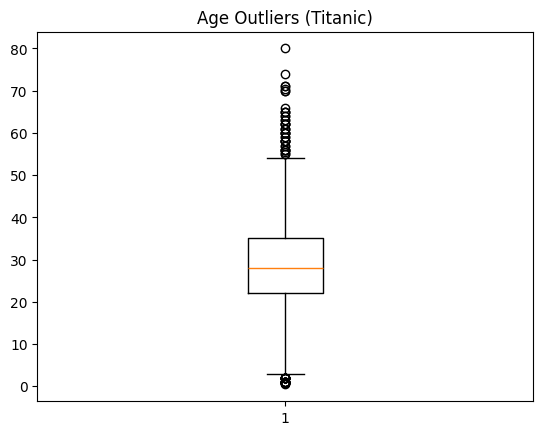

In [20]:
plt.boxplot(df['Age'].dropna())
plt.title("Age Outliers (Titanic)")
plt.show()

In [21]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

In [22]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [23]:
df['Age'] = df['Age'].clip(lower=lower_bound, upper=upper_bound)
# df['Age'] = df['Age'].apply(lambda x: upper_bound if x > upper_bound else x)

### 5.2 Fare Column
`Fare` is heavily right-skewed with 116 outliers. We cap values at the IQR bounds using `.clip()`.

Text(0.5, 1.0, 'Fare Outliers (Titanic)')

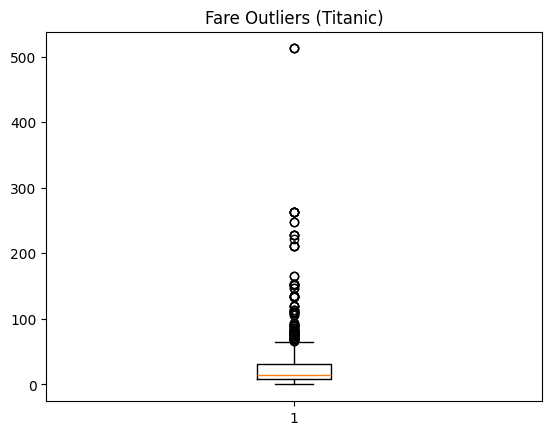

In [24]:
plt.boxplot(df['Fare'].dropna())
plt.title("Fare Outliers (Titanic)")

In [25]:
FareMedian = df['Fare'].median()

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Replace only true outliers in ONE step
df['Fare'] = df['Fare'].apply(
    lambda x: FareMedian if (x < lower_bound or x > upper_bound) else x
)

In [26]:
df['Fare'] = df['Fare'].clip(lower=lower_bound, upper=upper_bound)

## 6. Format & Standardize Columns

### 6.1 Sex Column
Standardize text casing — e.g., `male` → `Male`, `FEMALE` → `Female`.

In [27]:
df['Sex'] = df['Sex'].str.title()

### 6.2 Survived Column
Replace numeric codes with descriptive labels: `0` → `Death`, `1` → `Survived`.

In [28]:
df['Survived'] = df['Survived'].replace({0: 'Death', 1: 'Survived'})

In [29]:
df['Survived']

0         Death
1      Survived
2      Survived
3      Survived
4         Death
         ...   
886       Death
887    Survived
888       Death
889    Survived
890       Death
Name: Survived, Length: 891, dtype: object

### 6.3 Embarked Column
Replace port codes with full names: `S` → Southampton, `C` → Cherbourg, `Q` → Queenstown.

In [30]:
df['Embarked'] = df['Embarked'].replace({'S': 'Southampton', 'C': 'Cherbourg','Q':'Queenstown'})

## 7. Fix Data Types

- `Age` → converted to `int` (no fractional ages after filling)
- `Fare` → kept as `float` for precision

In [31]:
df['Age'] = df['Age'].astype(int)
df['Fare'] = df['Fare'].astype(float)

### Verify Final Schema

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    object 
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(1), int64(4), object(1), str(2)
memory usage: 55.8+ KB


In [33]:
df.describe()

,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,28.993266,0.523008,0.381594,17.383622
std,0.836071,12.050734,1.102743,0.806057,12.713016
min,1.000000,2.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,35.000000,1.000000,0.000000,24.150000
max,3.000000,54.000000,8.000000,6.000000,65.000000


## 8. Remove Duplicate Rows

After formatting and transformations, some rows may now look identical. We remove duplicates **at the end** to catch any new ones created during cleaning.

In [34]:
df.duplicated().sum()

np.int64(134)

In [35]:
df.drop_duplicates(inplace = True)

In [36]:
df.duplicated().sum()

np.int64(0)

## 9. Save Cleaned Data

Export the cleaned dataset to a new CSV file for future use.

In [37]:
df.to_csv('cleaned_titanic_data.csv', index = False)

## 10. Data Cleaning Report

A summary of all cleaning steps performed on the dataset.

In [38]:
print("DATA CLEANING REPORT")
print("--------------------")

print("Rows:", df.shape[0])

print("Columns:", df.shape[1])

print(
"Missing Values:",
df.isnull().sum().sum()
)

print(
"Duplicates:",
df.duplicated().sum()
)

DATA CLEANING REPORT
--------------------
Rows: 757
Columns: 8
Missing Values: 0
Duplicates: 0
